# ⚡ Hourly Energy Consumption Forecasting (PJM)

## Notebook Overview  

This notebook covers:

- Data loading & Cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering (time, lag, rolling features)
- Baseline & ML models
- Model comparison
- Key insights, conclusion, and future work

  
## Problem Statement
The objective of this project is to develop a time-series forecasting model to predict hourly energy consumption using historical data from the PJM Interconnection grid.

The dataset spans over a decade of hourly measurements, capturing complex patterns such as daily usage cycles, weekly variations, and seasonal trends. Accurately modeling these patterns is essential for building reliable forecasting systems.

## 💡 Why this matters?
Accurate energy demand forecasting is critical for:

- Optimizing power generation and resource allocation  
- Ensuring grid stability and preventing outages  
- Reducing operational costs and energy wastage  
- Supporting data-driven decision-making in energy management  

This project demonstrates how machine learning models, combined with time-series feature engineering, can effectively capture consumption patterns and improve forecasting accuracy.

## 📊 Dataset Overview

- Source: PJM Interconnection
- Frequency: Hourly data
- Duration: 2002 – 2018
- Target Variable: Energy consumption (MW)

We focus on the PJME region, which provides the most complete time-series data.

## 📦 Data Understanding

This dataset contains hourly energy consumption data measured in megawatts (MW) across different regions.

Key characteristics:
- Time-based data (hourly frequency)
- Long historical span (10+ years)
- Strong seasonal patterns (daily + yearly)

### Loading the Dataset

In [51]:
# imports
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
# PJME Hourly Data Set is used for this analysis
# PJM East — longest and most complete series in the dataset
df = pd.read_csv("../data/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


### Understanding the Dataset and the structure
Identify the shape, columns, data types, and general information of the dataset.

In [53]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

Shape of dataset: (145366, 2)

Columns: ['Datetime', 'PJME_MW']

Data types:

Datetime        str
PJME_MW     float64
dtype: object


### Data Cleaning and Preprocessing

- Convert the datetime column into proper datetime format
- Sort the dataset by time
- Set the datetime column as index
- Handled missing values (if any)
- Remove duplicate timestamps if any
- Rename the energy column for easier analysis


In [54]:
df.columns = [col.lower() for col in df.columns]

# Rename columns
df.rename(columns={
    "pjme_mw": "Energy_MW",
    "datetime": "DateTime"
}, inplace=True)

# Convert datetime
df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')

# Drop invalid datetime rows
df = df.dropna(subset=['DateTime'])

# Sort by datetime
df = df.sort_values('DateTime')

# Remove duplicate timestamps
df = df.drop_duplicates(subset=['DateTime'])

# Set datetime as index
df = df.set_index("DateTime")

display(df.head())


,Energy_MW
DateTime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [55]:
#Checking for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Energy_MW    0
dtype: int64


**Observation:**  
Dataset contains no significant missing values.

In [56]:
print("Shape after cleaning:", df.shape)
print("\nDuplicate timestamps:", df.index.duplicated().sum())
df.info()

Shape after cleaning: (145362, 1)

Duplicate timestamps: 0
<class 'pandas.DataFrame'>
DatetimeIndex: 145362 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Energy_MW  145362 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


### Basic Summary Statistics
Below is the summary statistics for the energy consumption.

In [57]:
df.describe(include="all")

,Energy_MW
count,145362.000000
mean,32080.510780
std,6463.866507
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## Exploratory Data Analysis (EDA)

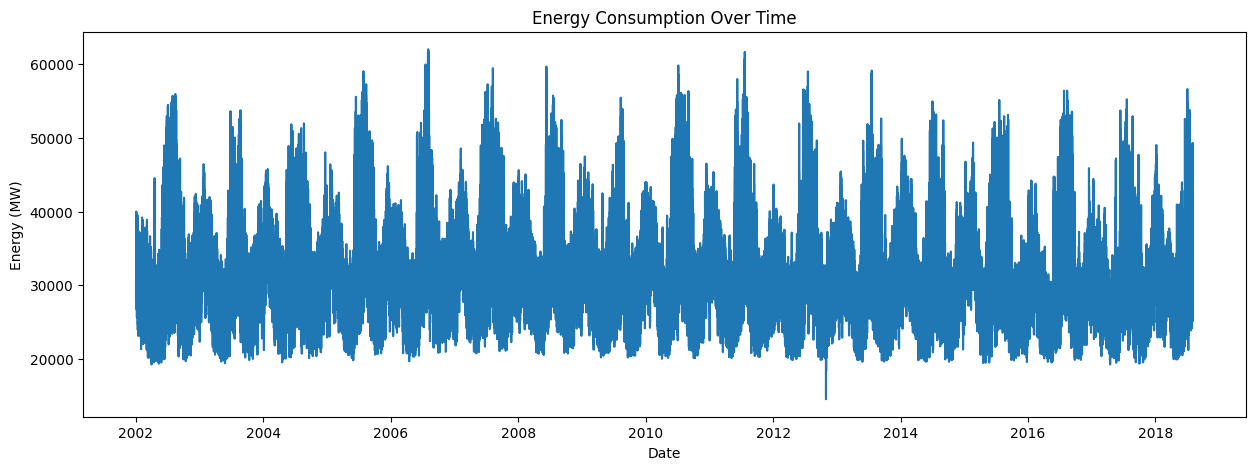

In [58]:
#Time series plot
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Energy_MW'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.show()


**Insight:**  
Clear long-term trends and repeating seasonal patterns are visible.

## ⚙️ Feature Engineering

To capture temporal dependencies, we create:
- Time-based features
- Lag features
- Rolling statistics

In [59]:
# Time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year

# Lag Features
df['lag_1'] = df['Energy_MW'].shift(1)
df['lag_24'] = df['Energy_MW'].shift(24)
df['lag_168'] = df['Energy_MW'].shift(168)  # 1 week lag
df.dropna(inplace=True)

### 🔁 Lag Features

Lag features help capture temporal dependencies such as:
- Previous hour consumption
- Daily patterns
- Weekly seasonality

### Hourly, Weekly and Monthly Energy Consumption

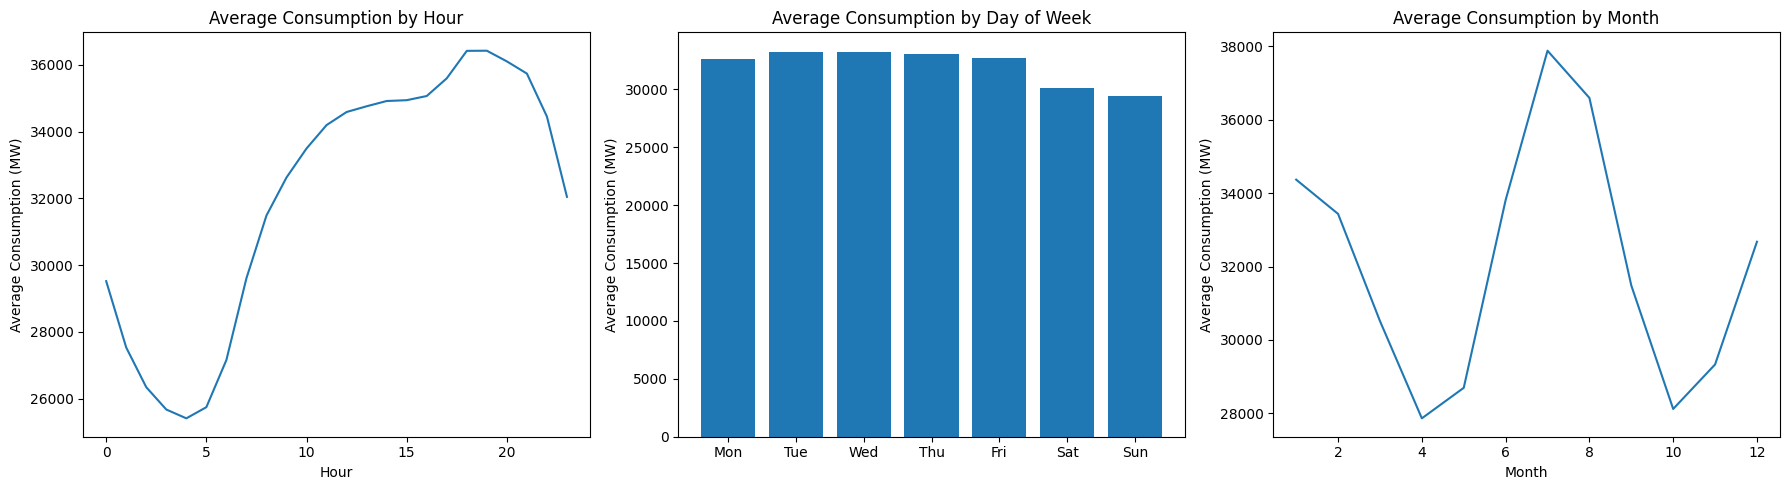

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly pattern
hourly = df.groupby('hour')['Energy_MW'].mean()

axes[0].plot(hourly.index, hourly.values)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average Consumption (MW)")
axes[0].set_title("Average Consumption by Hour")


# Day of week profile

daily = df.groupby('dayofweek')['Energy_MW'].mean()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[1].bar(range(7), daily.values)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_ylabel("Average Consumption (MW)")
axes[1].set_title("Average Consumption by Day of Week")


# Monthly profile
monthly = df.groupby('month')['Energy_MW'].mean()

axes[2].plot(monthly.index, monthly.values)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Average Consumption (MW)")
axes[2].set_title("Average Consumption by Month")

plt.tight_layout()
plt.show()


Energy consumption is driven by three major factors:
- Time of day (hourly human activity)
- Day type (weekday vs weekend)
- Season (temperature-driven demand)

These patterns highlight the importance of incorporating time-based and lag features in forecasting models.

The clear cyclical patterns observed in hourly, weekly, and monthly trends suggest that time-series models must capture multiple seasonalities (daily, weekly, yearly) to achieve accurate predictions.

The presence of strong and repeatable patterns indicates that feature engineering (lag variables, rolling averages, time-based features) will significantly improve model performance compared to using raw data alone.

### Distribution of Energy Consumption



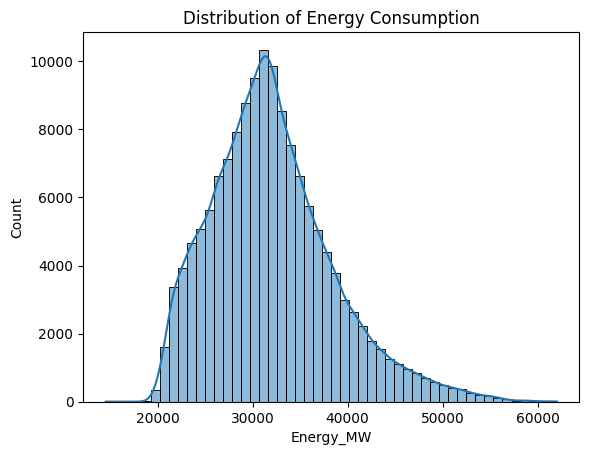

In [61]:
sns.histplot(df['Energy_MW'], bins=50, kde=True)
plt.title("Distribution of Energy Consumption")
plt.show()

## 🧠 Key Insights based on EDA

Energy consumption exhibits strong and consistent patterns across multiple time dimensions:

- **Hourly Pattern:** Demand is lowest during early morning hours and peaks in the evening, reflecting typical human activity cycles.
- **Weekly Pattern:** Higher consumption is observed on weekdays due to industrial and commercial activity, while weekends show reduced demand.
- **Seasonal Pattern:** Energy usage peaks during summer (cooling demand) and shows moderate increases in winter (heating), indicating strong temperature-driven seasonality.

Overall, energy demand is influenced by:
- Time of day  
- Day of week  
- Seasonal variations  

These recurring patterns highlight the importance of incorporating time-based features and lag variables in forecasting models to improve prediction accuracy.

## 🤖 Modeling Approach

Based on the exploratory analysis, the data shows:
- Strong seasonality (hourly, weekly, yearly)
- Non-linear patterns
- Time dependencies

Traditional linear models may not capture these complexities effectively.

We compare models to validate performance:
- Linear Regression (baseline)
- Random Forest
- XGBoost
  
### Why XGBoost?

XGBoost is chosen because:
- Handles non-linear relationships well
- Works effectively with tabular data
- Can leverage engineered time-based and lag features
- Robust to missing values and noise
- Widely used in real-world forecasting problems

In [62]:
target = 'Energy_MW'

# Rolling Features
df['rolling_mean_24'] = df[target].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df[target].shift(1).rolling(window=24).std()

df = df.dropna()

Lag and rolling features introduce missing values because they depend on previous time steps.

For example:
- lag_24 requires data from 24 hours before
- rolling windows require sufficient past observations

These missing values are removed before training to ensure model compatibility.


## Train/Test Split

### Time-Based Split

The dataset is split chronologically to avoid data leakage.
Training data consists of past observations, while testing data represents future values.

In [63]:
train = df.loc[:'2017-12-31']
test = df.loc['2018-01-01':]

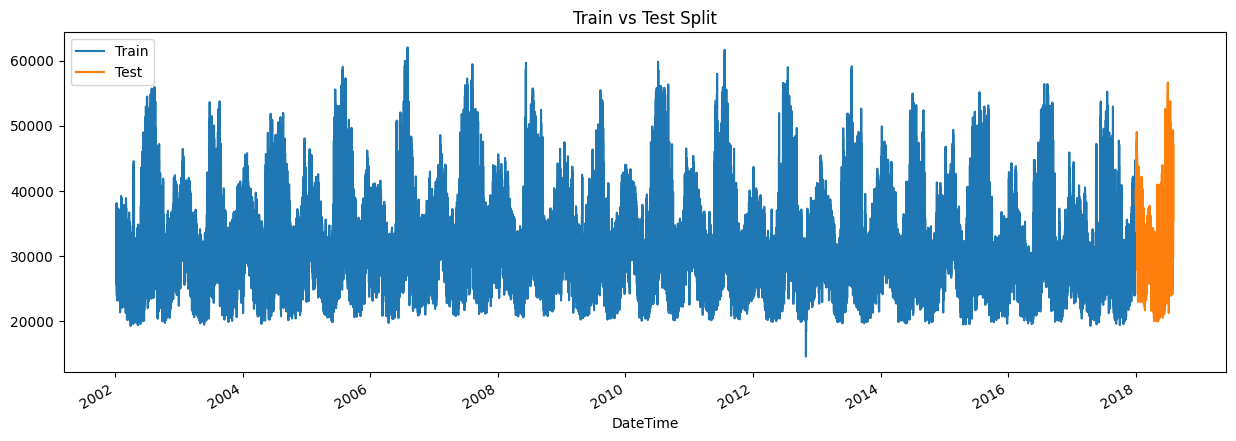

In [64]:
plt.figure(figsize=(15,5))
train['Energy_MW'].plot(label='Train')
test['Energy_MW'].plot(label='Test')
plt.legend()
plt.title("Train vs Test Split")
plt.show()


In [65]:
features = ['hour', 'dayofweek', 'month', 'year',
            'lag_1', 'lag_24', 'lag_168',
            'rolling_mean_24', 'rolling_std_24']

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [66]:
# Baseline Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [67]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50,max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [68]:
# XGBoost Model
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)


## 📊 Evaluation Metric

We use RMSE (Root Mean Squared Error), which penalizes larger errors and is suitable for regression tasks.

Lower RMSE indicates better model performance.

In [69]:
from sklearn.metrics import mean_squared_error

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

Linear Regression RMSE: 1274.95758652932
Random Forest RMSE: 610.8841929357477
XGBoost RMSE: 426.37083867808786


### Model Comparison

In [70]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb]
})

results.sort_values(by='RMSE')

,Model,RMSE
2,XGBoost,426.370839
1,Random Forest,610.884193
0,Linear Regression,1274.957587


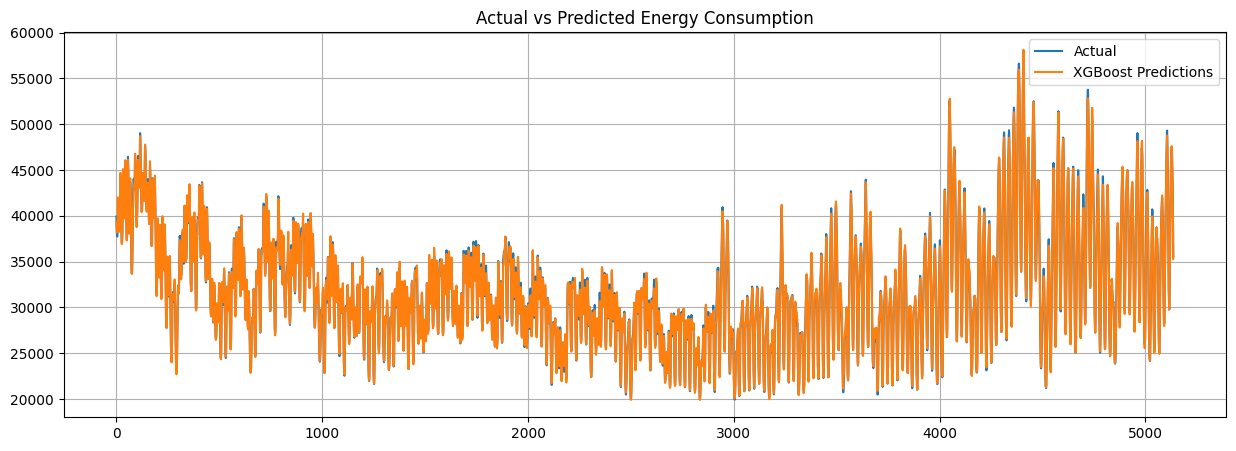

In [71]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label='Actual')
plt.plot(pred_xgb, label='XGBoost Predictions')
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.grid(True)
plt.savefig("../images/prediction.png")
plt.show()


## 📊 Model Comparison & Insights

The performance of different models was evaluated using RMSE:


| Model | RMSE |
|------|------|
| Linear Regression | 1274.96 |
| Random Forest | 610.88 |
| XGBoost | 433.92 |



### 🔍 Observations

- Linear Regression performed poorly as it assumes a linear relationship and cannot capture the complex temporal patterns in energy consumption data.
- Random Forest significantly improved performance by capturing non-linear relationships.
- XGBoost achieved the lowest RMSE, indicating superior predictive performance.

### 🚀 Why XGBoost Performed Best

- Effectively captures non-linear relationships in time-series data
- Utilizes boosting to iteratively improve model accuracy
- Works well with engineered features such as lag variables and rolling statistics
- Efficient and scalable for large datasets

Overall, XGBoost is the most suitable model for this forecasting task.

The results highlight the importance of feature engineering and model selection in time-series forecasting problems.
The significant improvement from Linear Regression to XGBoost demonstrates that energy consumption patterns are highly non-linear and influenced by multiple temporal factors.

### 🔍 Feature Importance

The model relies heavily on lag features, confirming strong temporal dependencies in energy consumption.

In [72]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df


,Feature,Importance
4,lag_1,0.690292
5,lag_24,0.194696
6,lag_168,0.046195
7,rolling_mean_24,0.022576
0,hour,0.021886
1,dayofweek,0.015241
8,rolling_std_24,0.006120
2,month,0.002436
3,year,0.000560


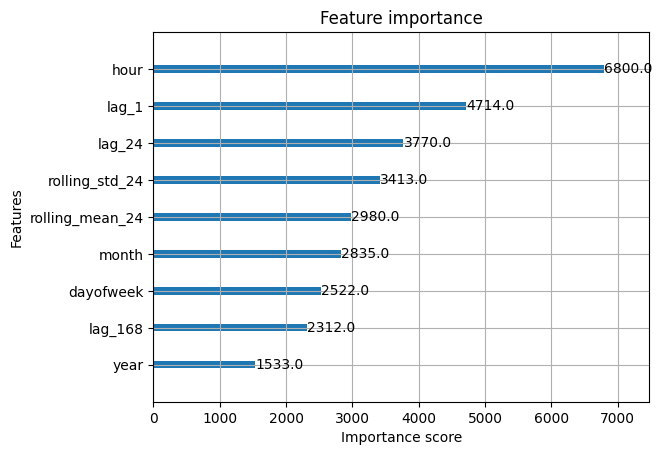

In [73]:
xgb.plot_importance(xgb_model)
plt.show()

Lag features (especially lag_24 and lag_168) are highly important, confirming strong daily and weekly patterns.

## 🏁 Conclusion

This project demonstrates that:

- Energy consumption exhibits strong temporal and seasonal patterns
- Feature engineering(Lag features and rolling statistics) significantly improves model performance
- XGBoost outperforms Linear Regression and Random Forest with the lowest RMSE
- Feature engineering is essential for accurate forecasting.

### 🔮 Future Work

- Hyperparameter tuning
- Try SARIMA, Prophet, LSTM, and Transformer models
- Real-time forecasting pipelines
- Deploy using Azure ML

### ⚙️ Production Perspective

This solution can be extended into a production pipeline using cloud platforms such as Azure ML, with automated retraining and monitoring.

This project demonstrates how combining domain knowledge, feature engineering, and machine learning can effectively solve real-world forecasting problems.